In [ ]:
%load_ext autoreload
%autoreload 2

# general
from pathlib import Path
import re
import numpy as np
import datetime
import matplotlib.pyplot as plt


# spatial
import xarray as xa

# custom
import cbsyst as cb
from cmipper import functions_creche, utils, config, parallelised_download_and_process, main, file_ops

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Testing cdo remap at high resolutions


In [96]:
test_env_ds = xa.open_dataset(Path("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/regridded/tos/tos_uncropped_sfc_ll_195001-195012.nc"))
test_bath_ds = xa.open_dataset(Path("/maps/rt582/coralshift/data/bathymetry/gebco/GEBCO_2023_n90-0_s90-0_w180-0_e180-0.nc"))
test_gt_ds = xa.open_dataset(Path("/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-004_S90-1_N90-1_W180-1_E180-1.nc"))

In [94]:
test_env_ds

<xarray.Dataset> Size: 44MB
Dimensions:  (time: 12, lon: 1440, lat: 641)
Coordinates:
  * time     (time) datetime64[ns] 96B 1950-01-16T12:00:00 ... 1950-12-16T12:...
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * lat      (lat) float64 5kB -78.74 -78.49 -78.24 -77.99 ... 80.76 81.01 81.26
Data variables:
    tos      (time, lat, lon) float32 44MB ...
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Apr 22 14:37:44 2024: cdo -O -s -remapbil,/maps-priv/ma...
    CDO:          Climate Data Operators version 2.3.0 (https://mpimet.mpg.de...

In [91]:
test_bath_ds

<xarray.Dataset> Size: 7GB
Dimensions:    (lon: 86400, lat: 43200)
Coordinates:
  * lon        (lon) float64 691kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat        (lat) float64 346kB -90.0 -89.99 -89.99 ... 89.99 89.99 90.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 7GB ...
Attributes: (12/36)
    title:                           The GEBCO_2023 Grid - a continuous terra...
    summary:                         The GEBCO_2023 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/f98b053b-0cbc-6c23-e053-6c8...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/f98b053b-0cbc-6c23-e053-6c8...
    references:                      DOI: 10.5285/f98b053b-0cbc-6c23-e053-6c8...
    node_offset:                     1.0

In [105]:
test_env_ds.info()

xarray.Dataset {
dimensions:
	time = 12 ;
	lon = 1440 ;
	lat = 641 ;

variables:
	datetime64[ns] time(time) ;
		time:standard_name = time ;
		time:long_name = time ;
		time:axis = T ;
	float64 lon(lon) ;
		lon:standard_name = longitude ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
		lon:axis = X ;
	float64 lat(lat) ;
		lat:standard_name = latitude ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
		lat:axis = Y ;
	float32 tos(time, lat, lon) ;
		tos:standard_name = sea_surface_temperature ;
		tos:long_name = Sea Surface Temperature ;
		tos:units = degC ;
		tos:comment = Temperature of upper boundary of the liquid ocean, including temperatures below sea-ice and floating ice shelves. ;
		tos:original_name = tos ;
		tos:cell_methods = area: mean where sea time: mean ;
		tos:cell_measures = area: areacello ;
		tos:history = 2018-09-22T14:27:27Z altered by CMOR: Reordered dimensions, original order: j i time. ;
		tos:_ChunkSizes = [  1 525 721] ;

// global attribu

In [107]:
test_gt_ds.lon.attrs["units"] = "degrees_east"
test_gt_ds.lat.attrs["units"] = "degrees_north"
test_gt_ds.info()

xarray.Dataset {
dimensions:
	lat = 16035 ;
	lon = 86399 ;

variables:
	float64 lat(lat) ;
		lat:units = degrees_north ;
	float64 lon(lon) ;
		lon:units = degrees_east ;
	float64 UNEP_GDCR(lat, lon) ;
		UNEP_GDCR:crs = EPSG:4326 ;

// global attributes:
}

In [92]:
test_gt_ds.rio.write_crs("EPSG:4326", inplace=True)

<xarray.Dataset> Size: 11GB
Dimensions:      (lat: 16035, lon: 86399)
Coordinates:
  * lat          (lat) float64 128kB -34.3 -34.29 -34.29 ... 32.51 32.51 32.51
  * lon          (lon) float64 691kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Data variables:
    UNEP_GDCR    (lat, lon) float64 11GB ...

In [98]:
test_gt_ds = test_gt_ds.rename({"latitude": "lat", "longitude": "lon"})

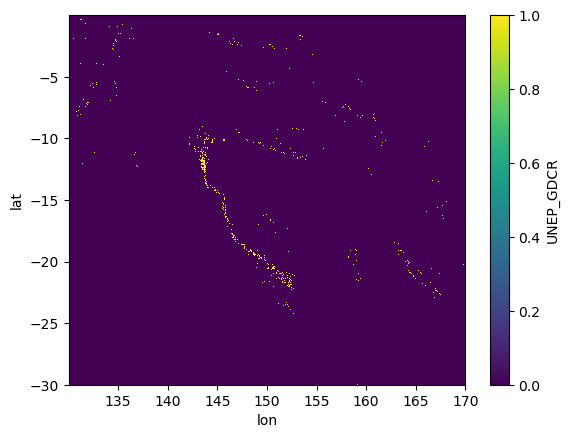

In [87]:
test_gt_ds.sel(lat=slice(-30,0), lon=slice(130,170)).UNEP_GDCR.plot()

linear-ing


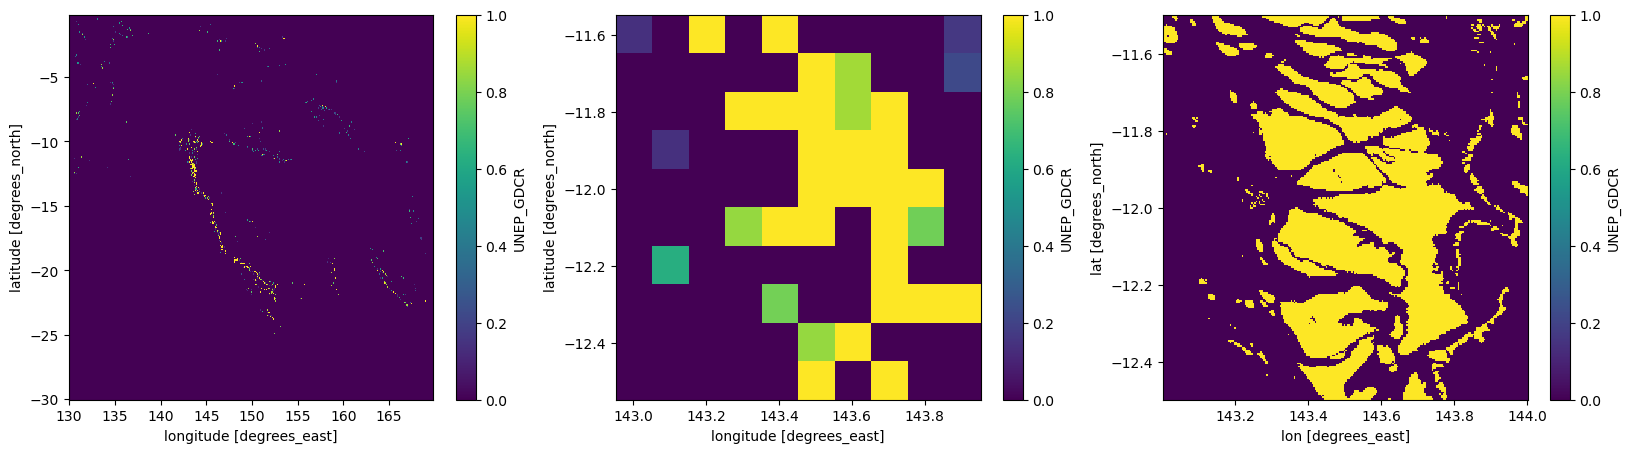

In [181]:
remap_template_fp = "/maps/rt582/cmipper/remap_test.txt"
utils.generate_remapping_file(test_gt_ds.sel(lat=slice(-30,-0), lon=slice(130,170)), remap_template_fp=remap_template_fp, resolutions = [0.1,0.1])

print("linear-ing")
remapped = utils.cdo_remap(test_gt_ds.sel(lat=slice(-30,-0), lon=slice(130,170)), remap_template_fp=remap_template_fp, remap_method="distance")
# print("summing")
# utils.generate_remapping_file(remapped.sel(lat=slice(-30,-0), lon=slice(130,160)), remap_template_fp=remap_template_fp, resolutions = [0.01,0.01])

# remapped = utils.cdo_remap(remapped.sel(lat=slice(-30,-0), lon=slice(130,160)), remap_template_fp=remap_template_fp, remap_method="sum")
# from cdo import Cdo
# cdo = Cdo()
# remapped = cdo.cdo.remapsum(r, input=input_object, returnXDataset=True)

f, a = plt.subplots(1,3, figsize=(20,5))
remapped["UNEP_GDCR"].plot(ax=a[0])
remapped.sel(lon=slice(143,144), lat=slice(-12.5, -11.5))["UNEP_GDCR"].plot(ax=a[1])
test_gt_ds.sel(lon=slice(143,144), lat=slice(-12.5, -11.5))["UNEP_GDCR"].plot(ax=a[2])

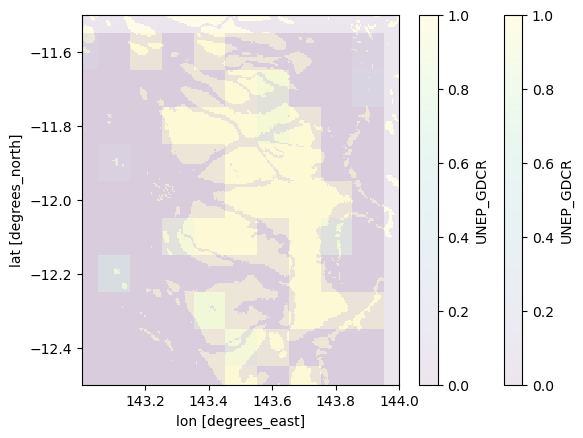

In [183]:
f,a =plt.subplots()
remapped.sel(lon=slice(143,144), lat=slice(-12.5, -11.5))["UNEP_GDCR"].plot(ax=a, alpha=0.1)
test_gt_ds.sel(lon=slice(143,144), lat=slice(-12.5, -11.5))["UNEP_GDCR"].plot(ax=a, alpha=0.1)

In [66]:
remap_template_fp = "/maps/rt582/cmipper/remap_test.txt"
utils.generate_remapping_file(test_bath_ds.sel(lat=slice(-30,0), lon=slice(130,170)), remap_template_fp = remap_template_fp, resolutions = [1,1])

In [67]:
test_env_ds_re = utils.cdo_remap(test_env_ds.sel(lat=slice(-30,0), lon=slice(130,170)), remap_template_fp=remap_template_fp)
test_bath_ds_re = utils.cdo_remap(test_bath_ds.sel(lat=slice(-30,0), lon=slice(130,170)), remap_template_fp=remap_template_fp)

In [71]:
test_env_ds_re = utils.cdo_remap_fly(test_env_ds.sel(lat=slice(-30,0), lon=slice(130,170)), resolutions=[0.1,0.1])
test_bath_ds_re = utils.cdo_remap_fly(test_bath_ds.sel(lat=slice(-30,0), lon=slice(130,170)), resolutions=[0.1,0.1])

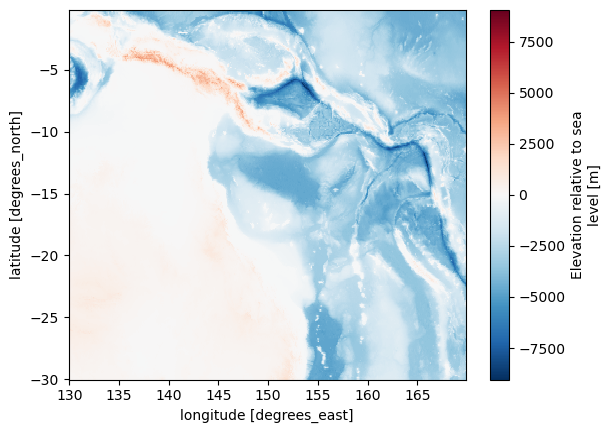

In [72]:
test_bath_ds_re.elevation.plot()

In [ ]:
merged = xa.merge([test_env_ds_re, test_bath_ds_re])
plt.imshow(merged["tos"].isel(time=0))

In [30]:
fps = Path("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/regridded/tos").glob("*.nc")
out = [fp for fp in fps]
small_nc = xa.open_mfdataset(out[:31])
ds = utils.cdo_remap_fly(small_nc.sel(lat=slice(-30,0), lon=slice(130,170)), [0.004, 0.004])

In [33]:
ds

<xarray.Dataset> Size: 111GB
Dimensions:  (time: 372, lon: 10000, lat: 7437)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1951-01-16T12:00:00 ... 2044-12-16T12:...
  * lon      (lon) float64 80kB -50.0 -50.0 -49.99 ... -10.01 -10.01 -10.0
  * lat      (lat) float64 59kB -29.99 -29.99 -29.98 ... -0.2557 -0.2517 -0.2477
Data variables:
    tos      (time, lat, lon) float32 111GB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Jun 25 11:03:04 2024: cdo -O -s -f nc -remapbil,/maps-p...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [6]:
small_nc

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 1200, lon: 1440, lat: 641)
Coordinates:
  * time     (time) datetime64[ns] 10kB 1950-01-16T12:00:00 ... 2049-12-16T12...
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * lat      (lat) float64 5kB -78.74 -78.49 -78.24 -77.99 ... 80.76 81.01 81.26
Data variables:
    tos      (time, lat, lon) float32 4GB dask.array<chunksize=(1, 641, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Apr 22 14:37:44 2024: cdo -O -s -remapbil,/maps-priv/ma...
    CDO:          Climate Data Operators version 2.3.0 (https://mpimet.mpg.de...

# Indexing to seafloor
Look into numpy.compress: https://github.com/pydata/xarray/issues/5054

In [ ]:
fps = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216").glob("*.nc")
combined = xa.open_mfdataset(fps, chunks={"lev": -1})   # levels as single chunk since will need to index along this dimension
# combined["time"] = [datetime.datetime(vv.year,vv.month,vv.day) for vv in combined["time"].values]   # from 360 calendar to datetime
combined

In [ ]:
print(f"ds size: {combined.nbytes * (2 ** -30):.0f} GB") # converting to GB)
print(f"Number of duplicated time values: {sum(combined["time"].to_dataframe().duplicated())}") # no duplicates

In [ ]:
small_ds = combined.isel(time=slice(0, 4))
print(f"small_ds size: {small_ds.nbytes * (2 ** -30):.0f} GB") # converting to GB)
mid_ds = combined.isel(time=slice(0, 8))
print(f"mid_ds size: {mid_ds.nbytes * (2 ** -30):.0f} GB") # converting to GB)
large_ds = combined.isel(time=slice(0, 16))
print(f"mid_ds size: {large_ds.nbytes * (2 ** -30):.0f} GB") # converting to GB)
larger_ds = combined.isel(time=slice(0, 100))
print(f"mid_ds size: {larger_ds.nbytes * (2 ** -30):.0f} GB") # converting to GB)

In [ ]:
seafloor_indices = utils.gen_seafloor_indices(larger_ds.isel(time=0, lev=slice(0,20)), "vo")

In [ ]:
def extract_seafloor_indices(ds, seafloor_indices, variable_id):
    print("Extracting...")
    new_ds = ds.copy()
    cmip6_array = utils.extract_3d_index_vals(new_ds[variable_id], seafloor_indices)
    new_ds[variable_id] = (["time", "j", "i"], cmip6_array)
    return new_ds


def seafloor(ds, var):
    seafloor_indices = utils.gen_seafloor_indices(ds.isel(time=0), var)
    proj_seafloor_indices = np.broadcast_to(
                seafloor_indices,
                (
                    len(ds.time),
                    len(ds.j),
                    len(ds.i),
                ),  # these variable names may differ by model
            )
    return extract_seafloor_indices(ds, proj_seafloor_indices, var)

In [ ]:
larger_ds["vo"].isel(lev=slice(0,20), time=0).load()

In [ ]:
def seafloor(ds, var):
    seafloor_indices = utils.gen_seafloor_indices(ds.isel(time=0), var)
    proj_seafloor_indices = np.broadcast_to(
                seafloor_indices,
                (
                    len(ds.time),
                    len(ds.j),
                    len(ds.i),
                ),  # these variable names may differ by model
            )
    return extract_seafloor_indices(ds, proj_seafloor_indices, var)

def convert_time(ds):
    ds["time"] = [datetime.datetime(vv.year,vv.month,vv.day) for vv in ds["time"].values]   # from 360 calendar to datetime
    return ds


def preprocess_ds(ds):
    ds = convert_time(ds)
    ds = seafloor(ds, "vo")
    return ds

In [ ]:
d = xa.open_dataset("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216/vo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_185001-185912.nc")
d = preprocess_ds(d)

In [ ]:
fps = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216").glob("*.nc")
new_combined = xa.open_mfdataset(fps, chunks={"lev": -1}, preprocess=preprocess_ds, parallel=True)   # levels as single chunk since will need to index along this dimension
# combined["time"] = [datetime.datetime(vv.year,vv.month,vv.day) for vv in combined["time"].values]   # from 360 calendar to datetime
new_combined

In [ ]:
new_combined["time"]

In [ ]:
seafloor(combined.isel(lev=slice(0,20)), "vo")

In [ ]:
new_combined = combined.copy()
new_combined[combined["vo"].name] = combined["vo"]

In [ ]:
new_combined

In [ ]:
def extract_seafloor_indices(ds, seafloor_indices):
    print("Extracting...")
    new_ds = ds.copy()
    cmip6_array = utils.extract_3d_index_vals(new_ds, seafloor_indices)
    # new_ds = (["time", "j", "i"], cmip6_array)
    # return new_ds
    return cmip6_array


def seafloor(ds):
    seafloor_indices = gen_seafloor_indices(ds.isel(time=0))
    proj_seafloor_indices = np.broadcast_to(
                seafloor_indices,
                (
                    len(ds.time),
                    len(ds.j),
                    len(ds.i),
                ),  # these variable names may differ by model
            )
    return extract_seafloor_indices(ds, proj_seafloor_indices)


def gen_seafloor_indices(xa_d: xa.Dataset, dim: str = "lev"):
    """Generate indices of seafloor values for a given variable in an xarray dataset.

    Args:
        xa_d (xa.Dataset): xarray dataset containing variable of interest
        var (str): name of variable of interest
        dim (str, optional): dimension along which to search for seafloor values. Defaults to "lev".

    Returns:
        indices_array (np.ndarray): array of indices of seafloor values for given variable
    """
    print("\ndetermining seafloor indices... ", flush=True)
    nans = np.isnan(xa_d).sum(dim=dim)  # separate out
    indices_array = -(nans.values) - 1
    indices_array[indices_array == -(len(xa_d[dim].values) + 1)] = -1
    return indices_array

In [ ]:
out = seafloor(combined["vo"].isel(lev=slice(0,20), time=slice(0,100)))

In [ ]:
out

In [ ]:
larger_proj_seafloor_indices = np.broadcast_to(
            seafloor_indices,
            (
                len(larger_ds.time),
                len(larger_ds.j),
                len(larger_ds.i),
            ),  # these variable names may differ by model
        )
larger_proj_seafloor_indices.shape

In [ ]:
combined_proj_seafloor_indices = np.broadcast_to(
            seafloor_indices,
            (
                len(combined.time),
                len(combined.j),
                len(combined.i),
            ),  # these variable names may differ by model
        )
combined_proj_seafloor_indices.shape

In [ ]:
proj_seafloor_indices = np.broadcast_to(
            seafloor_indices,
            (
                len(small_ds.time),
                len(small_ds.j),
                len(small_ds.i),
            ),  # these variable names may differ by model
        )
proj_seafloor_indices.shape

In [ ]:
mid_proj_seafloor_indices = np.broadcast_to(
            seafloor_indices,
            (
                len(mid_ds.time),
                len(mid_ds.j),
                len(mid_ds.i),
            ),  # these variable names may differ by model
        )
mid_proj_seafloor_indices.shape

In [ ]:
large_proj_seafloor_indices = np.broadcast_to(
            seafloor_indices,
            (
                len(large_ds.time),
                len(large_ds.j),
                len(large_ds.i),
            ),  # these variable names may differ by model
        )
large_proj_seafloor_indices.shape

In [ ]:
small_ds

In [ ]:
def extract_seafloor_indices(ds, seafloor_indices, variable_id):
    new_ds = ds.copy()
    cmip6_array = utils.extract_3d_index_vals(new_ds[variable_id], seafloor_indices)
    new_ds[variable_id] = (["time", "j", "i"], cmip6_array)
    return new_ds

# linear relationship between number of timesteps and time to extract
# %timeit extracted_ds = extract_seafloor_indices(small_ds, proj_seafloor_indices, "vo")    # 9.33 s ± 95.3 ms per loop
# %timeit extracted_ds = extract_seafloor_indices(mid_ds, mid_proj_seafloor_indices, "vo")    # 18.3 s ± 230 ms per loop
# %timeit extracted_ds = extract_seafloor_indices(large_ds, large_proj_seafloor_indices, "vo")    # 34.3 s ± 450 ms per loop
%timeit extracted_ds = extract_seafloor_indices(larger_ds.isel(lev=slice(0,20)), larger_proj_seafloor_indices, "vo")    # 34.3 s ± 450 ms per loop

In [ ]:
extracted_ds = extract_seafloor_indices(larger_ds.isel(lev=slice(0,20)), larger_proj_seafloor_indices, "vo")

In [ ]:
seafloor_vo = extract_seafloor_indices(combined, combined_proj_seafloor_indices, "vo")

In [ ]:
cmip6_array = utils.extract_3d_index_vals(small_ds["vo"], proj_seafloor_indices)

In [ ]:
cmip6_array.shape

In [ ]:
small_ds_ind = small_ds.copy()
small_ds_ind["vo"] = (["time", "j", "i"], cmip6_array)

In [ ]:
print(f"small_ds indexed size: {small_ds_ind.nbytes * (2 ** -30):.09f} GB") # converting to GB)

In [ ]:
def extract_seafloor_vals_from_ds(ds, variable_id):
    # Generate seafloor indices in parallel
    seafloor_indices = utils.gen_seafloor_indices(ds, var=variable_id)
    seafloor_indices = np.broadcast_to(
        seafloor_indices,
        (
            len(ds.time),
            len(ds.j),
            len(ds.i),
        ),  # these variable names may differ by model
    )
    
    print("\n\textracting seafloor values...", flush=True)
    return extract_seafloor_indices(larger_ds, seafloor_indices, variable_id)
    
    # # Use Dask to apply the extraction function
    # cmip6_array = xa.apply_ufunc(
    #     utils.extract_3d_index_vals,
    #     ds[variable_id],
    #     seafloor_indices,
    #     # input_core_dims=[['time', 'lev', 'j', 'i'], []],
    #     # output_core_dims=[['time', 'j', 'i']],
    #     dask='parallelized',
    #     output_dtypes=[np.float32]
    # )
    
    # ds[variable_id] = cmip6_array
    # return ds, seafloor_indices

extract_seafloor_vals_from_ds(combined.isel(time=slice(0, 4), lev=slice(0, 20)), "vo")


In [ ]:
check = utils.extract_seafloor_vals(combined.isel(time=slice(0,20)), "vo")  # 10 time steps = 47s (60s parallelised), 20 time steps = 1m 20s

In [ ]:
utils.extract_seafloor_vals(combined, "vo")

In [ ]:
fps = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/vo/gn/v20191216").glob("*.nc")
combined = xa.open_mfdataset(fps)

In [ ]:
combined["vo"].isel(time=0, lev=0).plot()

# Calculating aragonite saturation state

In [ ]:
import cftime
import pandas as pd

def convert_cftime_to_timestamp(ds):
    # Check the calendar type of the dataset
    calendar = ds.time.encoding.get('calendar', 'standard')
    
    # Get the units from the 'attrs' dictionary
    units = ds.time.attrs.get('units', None)
    
    # Convert cftime objects to pandas Timestamps if units are available
    if units:
        time_values = ds.time.values
        if isinstance(time_values[0], cftime.Datetime360Day):
            time_stamps = [pd.Timestamp(cftime.num2date(time_val, units=units, calendar=calendar)) for time_val in time_values]
            ds['time'] = time_stamps
        else:
            print("Time values are not in cftime.Datetime360Day format.")
    else:
        print("Units for the time coordinate are not available.")
    
    return ds

tos = convert_cftime_to_timestamp(tos)


In [ ]:
dic = xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/dissic/dissic_uncropped_sfl-20_ll_185001-185412.nc")
tos = xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/regridded/tos/tos_uncropped_sfc_ll_185001-186912.nc")
so = xa.open_dataset("data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/regridded/so/so_uncropped_sfl-20_ll_195001-195012.nc")
regridded_dic = utils.process_xa_d(utils.cdo_remap(
    dic, remap_template_fp="/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/HadGEM3-GC31-MM_remap_template.txt"
))
regridded_so = utils.process_xa_d(utils.cdo_remap(
    so, remap_template_fp="/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/HadGEM3-GC31-MM_remap_template.txt"
))

dss = [tos.isel(time=0), regridded_dic.isel(time=0), regridded_so.isel(time=0)]

In [ ]:
merged = xa.merge(dss, compat="override")

In [ ]:
# example values before optimising for arrays
T = merged.isel(latitude=100, longitude=100)["tos"].values
DIC = merged.isel(latitude=100, longitude=100)["dissic"].values
S = merged.isel(latitude=100, longitude=100)["so"].values

In [ ]:
cb.CBsys(DIC=DIC, T_in=T, S_in=S)

# Optimising regridding

In [ ]:
def calculate_chunk_size(ds, max_chunk_mb=450):
    """
    Calculate optimal chunk sizes for an xarray dataset given a maximum chunk size in MB.
    
    Parameters:
    ds (xarray.Dataset): The xarray dataset.
    max_chunk_mb (int): Maximum chunk size in MB (default is 450MB).
    
    Returns:
    dict: A dictionary of chunk sizes for the dataset.
    """
    # Convert max chunk size to bytes
    max_chunk_bytes = max_chunk_mb * 1024 * 1024
    
    # Size of each data point in bytes (assuming float32)
    bytes_per_value = 4
    
    # Get the sizes of the dimensions
    lev_size = ds.dims['lev']
    i_size = ds.dims['i']
    j_size = ds.dims['j']
    
    # Determine the maximum size for i and j
    ij_chunk_size = int((max_chunk_bytes // (bytes_per_value * lev_size * i_size * j_size)) ** 0.5)
    
    # Calculate the chunk size for the time dimension
    time_chunk_size = max_chunk_bytes // (bytes_per_value * lev_size * ij_chunk_size * ij_chunk_size)
    
    # Create the chunk sizes dictionary
    chunks = {'time': time_chunk_size, 'lev': lev_size, 'i': ij_chunk_size, 'j': ij_chunk_size}
    
    return chunks


ds = xa.open_dataset(
    "https://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/rsdo/gn/v20191216/rsdo_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc")

calculate_chunk_size(ds)    

In [ ]:
parallelised_download_and_process.main(source_id="HadGEM3-GC31-MM", variable_id="vo", member_id="r1i1p1f3")

In [ ]:
url = "http://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/hfds/gn/v20191207/hfds_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_185001-186912.nc"
# out = xa.open_dataset(url, ).load()
out = xa.open_dataset(url)


In [ ]:
# load_out = xa.open_dataset(url, chunks={"time": "500MB"}) # Authorization issue
# load_out = xa.open_dataset(url, chunks={"time": 100}).load()    # Authorization issue
# load_out = xa.open_dataset(url, chunks={"i": 180, "j": 180}).load()     # 9m 43s
load_out = xa.open_dataset(url, chunks={"time": 72}).load()   # 3m 22s
# load_out = xa.open_dataset(url, chunks={"time": 50}).load()   # 3m 35s
# load_out = xa.open_dataset(url, chunks={"time": 10}).load()   # 3m 40s

In [ ]:
load_out.isel(time=0)["hfds"].plot()

In [ ]:
out.isel(time=0)["hfds"].plot()

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/og_grid/mlotst/mlotst_uncropped_sfc_tp_201001-201412.nc")

In [ ]:
test = xa.open_dataset("http://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/mlotst/gn/v20191207/mlotst_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc")
test

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(test.latitude.values)

In [ ]:
test.isel(time=0)["mlotst"].plot()

In [ ]:
test_load = xa.open_dataset("http://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/mlotst/gn/v20191207/mlotst_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc",
    chunks={"time": 60}).load()   # 3m 22s

In [ ]:
test_load.isel(time=0)["mlotst"].plot()

In [ ]:
xa.open_dataset("/maps-priv/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/og_grid/mlotst/mlotst_uncropped_sfc_tp_201001-201412.nc").isel(time=0)["mlotst"].plot()

In [ ]:
xa.open_dataset("http://esgf-data1.llnl.gov/thredds/dodsC/css03_data/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/historical/r1i1p1f3/Omon/mlotst/gn/v20191207/mlotst_Omon_HadGEM3-GC31-MM_historical_r1i1p1f3_gn_201001-201412.nc").isel(time=0)["mlotst"].plot()

gridtype = latlon
xsize = 1440
ysize = 1205
xfirst = -180.0
yfirst = -89.48750305175781
xinc = 0.25
yinc = 0.14890901557637448


In [ ]:
xa.open_dataset('/maps-priv/maps/rt582/cmipper/data/env_vars/cmip6/HadGEM3-GC31-MM/r1i1p1f3/og_grid/mlotst/mlotst_uncropped_sfc_tp_195001-196912.nc')

In [ ]:
parallelised_download_and_process.generate_bash_commands()

In [ ]:
parallelised_download_and_process.main(source_id="HadGEM3-GC31-MM", variable_id="uo", member_id="r1i1p1f3")

In [ ]:
def limit_model_info_dict(model: dict, download: dict):
    """
    Limit the model info dict to only the data that is specified for the download.
    """
    return {
        source_id: {
            "resolution": source_data["resolution"],
            "experiment_ids": [
                exp_id
                for exp_id in source_data["experiment_ids"]
                if exp_id in download["experiment_ids"]
            ],
            "member_ids": [
                member_id
                for member_id in source_data["member_ids"]
                if member_id in download["member_ids"]
            ],
            "data_nodes": source_data["data_nodes"],
            "frequency": source_data["frequency"],
            "variable_dict": {
                var_id: var_data
                for var_id, var_data in source_data["variable_dict"].items()
                if var_id in download["variable_ids"]
            },
        }
        for source_id, source_data in model.items()
        if any(
            var_id in download["variable_ids"]
            for var_id in source_data["variable_dict"]
        )
    }


model_info = file_ops.read_yaml(config.model_info)
download_info = file_ops.read_yaml(config.download_config)

limit_model_info_dict(model_info, download_info)

In [ ]:
def extract_matching_subsets(first_dict, second_dict):
    matching_subsets = {}

    for model in first_dict:
        if model in second_dict:
            matching_subsets[model] = {}

            # Extract matching variable_ids
            first_var_ids = set(first_dict[model].get('variable_ids', []))
            second_var_dict = second_dict[model].get('variable_dict', {})
            matching_var_ids = {var: second_var_dict[var] for var in first_var_ids if var in second_var_dict}
            if matching_var_ids:
                matching_subsets[model]['variable_dict'] = matching_var_ids

            # Extract matching member_ids
            first_member_ids = set(first_dict[model].get('member_ids', []))
            second_member_ids = set(second_dict[model].get('member_ids', []))
            matching_member_ids = list(first_member_ids.intersection(second_member_ids))
            if matching_member_ids:
                matching_subsets[model]['member_ids'] = matching_member_ids

            # Extract matching experiment_ids
            first_experiment_ids = set(first_dict[model].get('experiment_ids', {}).keys())
            second_experiment_ids = set(second_dict[model].get('experiment_ids', []))
            matching_experiment_ids = list(first_experiment_ids.intersection(second_experiment_ids))
            if matching_experiment_ids:
                matching_subsets[model]['experiment_ids'] = matching_experiment_ids

    return matching_subsets

# Example usage
first_dict = {
    'EC-Earth3P-HR': {
        'variable_ids': ['hfds', 'rsdo', 'mlotst', 'so', 'thetao', 'uo', 'vo', 'wfo', 'tos'],
        'member_ids': ['r1i1p2f1'],
        'experiment_ids': {
            'hist-1950': [1950, 2015],
            'highres-future': [2015, 2050]
        },
        'lats': [-32, -0],
        'lons': [130, 170],
        'levs': [0, 20],
        'processing': {
            'do_regrid': True,
            'do_delete_og': False
        }
    },
    'MPI-ESM1-2-HR': {
        'variable_ids': ['no3', 'po4', 'dissic'],
        'member_ids': ['r1i1p1f1'],
        'experiment_ids': {
            'historical': [1850, 2015]
        },
        'processing': {
            'do_regrid': True,
            'do_regrid_on_fly': True,
            'do_save_og': False,
            'do_delete_og': False,
            'do_crop': False,
            'remap_to': 'latlon',
            'remap_method': 'bilinear',
            'lats': [-10, -0],
            'lons': [130, 140],
            'levs': [0, 20]
        }
    }
}

second_dict = {
    # 'EC-Earth3P-HR': {
    #     'resolution': 0.25,
    #     'experiment_ids': ['hist-1950', 'highres-future'],
    #     'member_ids': ['r1i1p2f1', 'r3i1p2f1'],
    #     'data_nodes': ['esgf-data1.llnl.gov'],
    #     'frequency': 'mon',
    #     'variable_dict': {
    #         'hfds': {'include': True, 'table_id': 'Omon', 'plevels': [None]},
    #         'rsdo': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'umo': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'vmo': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'mlotst': {'include': True, 'table_id': 'Omon', 'plevels': [None]},
    #         'so': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'thetao': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'uo': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'vo': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
    #         'wfo': {'include': True, 'table_id': 'Omon', 'plevels': [None]},
    #         'tos': {'include': True, 'table_id': 'Omon', 'plevels': [None]}
    #     }
    # },
    'MPI-ESM1-2-HR': {
        'resolution': 0.5,
        'experiment_ids': ['historical'],
        'member_ids': ['r1i1p1f1'],
        'data_nodes': ['esgf-data1.llnl.gov', 'esgf.ceda.ac.uk', 'esgf3.dkrz.de', 'cmip.bcc.cma.cn'],
        'frequency': 'mon',
        'variable_dict': {
            'no3': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
            'po4': {'include': True, 'table_id': 'Omon', 'plevels': [-1]},
            'dissic': {'include': True, 'table_id': 'Omon', 'plevels': [-1]}
        }
    }
}

matching_subsets = extract_matching_subsets(first_dict, second_dict)
print(matching_subsets)


In [ ]:
parallelised_download_and_process.generate_bash_commands()

In [ ]:
fps = Path("/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/no3").glob("*.nc")
xa.open_mfdataset(fps)

In [ ]:
xa.open_dataset("/maps-priv/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/regridded/no3/no3_uncropped_sfl-20_ll_200001-200412.nc")

In [ ]:
# open yaml
file_ops.read_yaml(config.download_config)


In [ ]:
og = xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/MPI-ESM1-2-HR/r1i1p1f1/og_grid/no3/no3_uncropped_sfl-20_tp_190001-190412.nc")
og

In [ ]:
all_gebco = xa.open_dataset("/maps/rt582/cmipper/temp_data/GEBCO_2023.nc")

In [ ]:
out = xa.open_dataset("/maps/rt582/coralshift/data/bathymetry/gebco/gebco_2023_n-10.0_s-30.0_w140.0_e160.0.nc")
out.sortby(list(out.dims)) 

In [ ]:
fps = ['/maps-priv/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-004_S90-1_N90-1_W180-1_E180-1.nc', '/maps-priv/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-004_S5-1_N0-1_E139-9_E145-1.nc']

In [ ]:
extract_lat_lon_ranges_from_fp(fps[0])

In [ ]:
file_ops.find_files_for_area(fps, lat_range=[-90.1,90.1], lon_range=[-180.1,180.1])

In [ ]:
pattern = re.compile(r"([nsew])(?=-?\d+)", re.IGNORECASE)

match = pattern.findall(fp)

directions = []
for direction in match:
    if direction.lower() == "n" or direction.lower() == "e":
        directions.append(1)
    else:
        directions.append(-1)

directions
        

In [ ]:
xa.open_dataset("/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/og_grid/tos/tos_uncropped_sfc_tp_200401-200412.nc")

In [ ]:
xa.open_dataset("/maps-priv/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/newtest/og_grid/mlotst/mlotst_uncropped_sfc_tp_199301-199312.nc")

In [ ]:
parallelised_download_and_process.delete_corrupt_files("EC-Earth3P-HR", "r1i1p2f1")

In [ ]:
main.main()